# Figure 8.5 — the bright-star failure mode and the $\sigma$-routed combination

Symptom → chance test → identity → fix, in one figure:

- **(a) Symptom**: head residual vs raw offset (i band, all S/N). The bulk sits below the 1:1 line
  (the head improves); a small population rides above it.
- **(b) Chance test**: fraction worsened vs raw offset (Rubin bands, S/N > 20) against the noise-floor
  expectation $\exp(-\mathrm{raw}^2/2\sigma_{\rm floor}^2)$, with $\sigma_{\rm floor}$ estimated per
  band × S/N tercile from large-raw sources only. Worsening concentrates exactly where the raw offset
  falls below the corrected floor, and the observed curve sits at or *below* the expectation because the
  head shares the classical centroid's pixels (correlated errors): the bulk of the above-1:1 cloud is
  benign regression to the floor.
- **(c) Identity**: rate of multi-band-coherent worsening (strongly worsened in $\geq 3$ Rubin bands,
  a subset that a marginal-preserving permutation null shows cannot be chance; nb23) vs VIS magnitude,
  split by MER morphology. Point sources ramp steeply toward the bright end; extended sources stay flat:
  the real offenders are bright stars.
- **(d–f) Fix**: offsets of bright Gaia stars vs PM-propagated Gaia DR3 (truth), on held-out tiles:
  classical centroids / head / correlation-aware $\sigma$-routed combination of the two.

Data: production Q1 eval archive with per-source $\sigma_{\rm pred}$
(`latent_position_q1_vissep/anchors_centernet_q1_vissep_sigma.npz`). Calibration of the router
(uncertainty scales, classical error table, raw–residual correlation $\rho$) uses only the *even*
md5-hash half of tiles; every plotted point in (d–f) and every router number is from the *odd* (test) half.
Full diagnosis in `io/23_astrometry_bright_worseners.ipynb`; router validation in `io/24_astrometry_sigma_router.ipynb`.

In [1]:
from pathlib import Path
import numpy as np, pandas as pd, pickle, hashlib
from scipy.spatial import cKDTree
from astropy.io import fits

def find_repo_root(s=None):
    s=(s or Path.cwd()).resolve()
    for c in [s,*s.parents]:
        if (c/'models').exists() and (c/'data').exists(): return c
    raise FileNotFoundError('repo root')
REPO=find_repo_root()
OUT=REPO/'paper'/'figures'/'fig8p5_sigma_router.png'
ARCH=REPO/'models/checkpoints/latent_position_q1_vissep/anchors_centernet_q1_vissep_sigma.npz'
CACHE=Path.cwd()/'_fig8p5_cache.pkl'
BANDS=['u','g','r','i','z','y','nisp_Y','nisp_J','nisp_H']; RUBIN=['u','g','r','i','z','y']

if CACHE.exists():
    long,pos,cosd=pickle.load(open(CACHE,'rb'))
    print('cache:',CACHE.name,'|',f'{len(long):,} measurements,',f'{long.src.nunique():,} sources')
else:
    d=np.load(ARCH,allow_pickle=True)
    cosd=np.cos(np.deg2rad(np.median(np.asarray(d['i_dec'],float))))
    def cluster(xy,r):
        """Union-find connected components of points within radius r [same units as xy]."""
        t=cKDTree(xy); pairs=t.query_pairs(r,output_type='ndarray')
        par=np.arange(len(xy))
        def f(a):
            while par[a]!=a: par[a]=par[par[a]]; a=par[a]
            return a
        for a,b in pairs:
            x,y=f(a),f(b)
            if x!=y: par[x]=y
        lab=np.array([f(i) for i in range(len(xy))]); _,lab=np.unique(lab,return_inverse=True); return lab
    # per band: collapse overlap-tile duplicates at 0.3", then cluster bands into canonical sources at 0.4"
    ent=[]
    for b in BANDS:
        ra=np.asarray(d[f'{b}_ra'],float); dec=np.asarray(d[f'{b}_dec'],float)
        raw=np.asarray(d[f'{b}_raw'],float)*1000.; res=np.asarray(d[f'{b}_head_resid'],float)*1000.
        snr=np.asarray(d[f'{b}_snr'],float); sig=np.asarray(d[f'{b}_sigma'],float)*1000.
        tl=np.asarray(d[f'{b}_tiles'])
        ok=np.isfinite(raw).all(1)&np.isfinite(res).all(1)&np.isfinite(snr)&(snr>0)&np.isfinite(sig)&(sig>0)
        lab=cluster(np.column_stack([ra[ok]*cosd*3600,dec[ok]*3600]),0.3)
        df=pd.DataFrame(dict(g=lab,ra=ra[ok],dec=dec[ok],rx=raw[ok,0],ry=raw[ok,1],
                             ex=res[ok,0],ey=res[ok,1],snr=snr[ok],sig=sig[ok],tile=tl[ok]))
        a=df.groupby('g').agg(ra=('ra','median'),dec=('dec','median'),rx=('rx','median'),ry=('ry','median'),
            ex=('ex','median'),ey=('ey','median'),snr=('snr','median'),sig=('sig','median'),
            tile=('tile','first')).reset_index(drop=True)
        a['band']=b; ent.append(a)
        print(f'{b:7s}: {ok.sum():6d} anchors -> {len(a):6d} unique sources')
    long=pd.concat(ent,ignore_index=True)
    long['src']=cluster(np.column_stack([long.ra*cosd*3600,long.dec*3600]),0.4)
    long=long.sort_values('snr',ascending=False).drop_duplicates(['src','band']).reset_index(drop=True)
    long['raw']=np.hypot(long.rx,long.ry); long['res']=np.hypot(long.ex,long.ey)
    long['calib']=long.tile.map(lambda t: int(hashlib.md5(str(t).encode()).hexdigest(),16)%2==0)
    # attach MER morphology + magnitude + Gaia
    pos=long.groupby('src')[['ra','dec']].median()
    hs=fits.open(REPO/'data/edf_s_ood/catalogs_compact/mer_q1_ECDFS_Hsize.fits')[1].data
    mc=fits.open(REPO/'data/edf_s_ood/catalogs_compact/mer_FINAL_q1_ECDFS_footprint.fits')[1].data
    def attach(cra,cdec,vals,rad=0.5):
        t=cKDTree(np.column_stack([np.asarray(cra,float)*cosd,np.asarray(cdec,float)]))
        dist,idx=t.query(np.column_stack([pos.ra*cosd,pos.dec]),k=1)
        return np.where(dist*3600<rad,np.asarray(vals,float)[idx],np.nan)
    pos['plike']=attach(hs['ra'],hs['dec'],hs['point_like_prob'])
    pos['vmag']=attach(mc['ra'],mc['dec'],mc['mag_vis'])
    gaia=np.load(REPO/'data/gaia_ecdfs_astrometry_cache.npz',allow_pickle=True)
    tg=cKDTree(np.column_stack([np.asarray(gaia['ra'],float)*cosd,np.asarray(gaia['dec'],float)]))
    gd,gi=tg.query(np.column_stack([pos.ra*cosd,pos.dec]),k=1)
    pos['gaia_i']=np.where(gd*3600<0.5,gi,-1)
    pos['is_star']=(pos.plike>0.7)|(pos.gaia_i>=0)
    long=long.join(pos[['vmag','is_star']],on='src')
    long['bright_star']=long.is_star&(long.vmag<19.5)
    pickle.dump((long,pos,cosd),open(CACHE,'wb'))
    print(f'{len(long):,} measurements, {long.src.nunique():,} sources; calibration half {long.calib.mean():.0%}')

cache: _fig8p5_cache.pkl | 153,016 measurements, 37,796 sources


## The $\sigma$-routed combination (calibrated on the even half, applied to the odd half)

$\sigma_{\rm pred}$ is rescaled by a two-tier reliability factor (global $\alpha$; separate factor for
bright stars, where the head is over-confident). The classical uncertainty $\sigma_{\rm cl}$ comes from a
(band, S/N bin, star/extended) table of robust raw-offset scales. Because the head reads the same pixels
as the classical centroid, their errors are correlated; with $\rho$ measured per (S/N bin, star/extended)
cell, the minimum-variance weight of the head is
$w^{*}=(\sigma_{\rm cl}^{2}-\rho\,\sigma_{\rm cl}\sigma_{h})/(\sigma_{\rm cl}^{2}+\sigma_{h}^{2}-2\rho\,\sigma_{\rm cl}\sigma_{h})$.

In [2]:
cal=long[long.calib].copy()
def obs_scale(g):
    return 1.4826*np.median(np.abs(np.concatenate([g.ex-g.ex.median(),g.ey-g.ey.median()])))
# sigma_pred reliability: global alpha + bright-star over-confidence factor
qb=np.quantile(cal.sig,np.linspace(0,1,9))
pred_c,obs_c=[],[]
for lo,hi in zip(qb[:-1],qb[1:]):
    g=cal[(cal.sig>=lo)&(cal.sig<=hi)]
    if len(g)>200: pred_c.append(g.sig.median()); obs_c.append(obs_scale(g))
alpha=float(np.median(np.array(obs_c)/np.array(pred_c)))
a_bs=obs_scale(cal[cal.bright_star])/cal[cal.bright_star].sig.median()
print(f'sigma_pred calibration: global alpha = {alpha:.2f}; bright stars alpha = {a_bs:.2f}')
long['sig_h']=np.where(long.bright_star,a_bs,alpha)*long.sig

# classical error table + raw-resid correlation, per (band, S/N bin, star/extended)
snr_edges=np.quantile(cal.snr,np.linspace(0,1,6))
def snr_bin(s): return np.clip(np.digitize(s,snr_edges[1:-1]),0,4)
cal['sb']=snr_bin(cal.snr); cal['st']=cal.is_star.fillna(False)
tab={}
for (b,sb,st),g in cal.groupby(['band','sb','st']):
    if len(g)>=60:
        tab[(b,sb,st)]=1.4826*np.median(np.abs(np.concatenate([g.rx-g.rx.median(),g.ry-g.ry.median()])))
fallback=1.4826*np.median(np.abs(np.concatenate([cal.rx-cal.rx.median(),cal.ry-cal.ry.median()])))
rho_tab={}
for (sb,st),g in cal.groupby(['sb','st']):
    if len(g)>300:
        r1=np.corrcoef(g.rx,g.ex)[0,1]; r2=np.corrcoef(g.ry,g.ey)[0,1]
        rho_tab[(sb,st)]=float(np.clip(0.5*(r1+r2),0,0.95))
rho_fb=float(np.median(list(rho_tab.values())))

# apply to the held-out (test) half
test=long[~long.calib].copy()
test['sb']=snr_bin(test.snr); test['st']=test.is_star.fillna(False)
test['sig_cl']=[tab.get((b,sb,st),fallback) for b,sb,st in zip(test.band,test.sb,test.st)]
test['rho']=[rho_tab.get((sb,st),rho_fb) for sb,st in zip(test.sb,test.st)]
# naive inverse-variance weight (shown only in the numbers below: it costs ~2 mas at the faint end)
test['w']=test.sig_cl**2/(test.sig_cl**2+test.sig_h**2)
test['comb']=np.hypot((1-test.w)*test.rx+test.w*test.ex,(1-test.w)*test.ry+test.w*test.ey)
# correlation-aware weight
num=test.sig_cl**2-test.rho*test.sig_cl*test.sig_h
den=test.sig_cl**2+test.sig_h**2-2*test.rho*test.sig_cl*test.sig_h
test['w2']=np.clip(num/den.clip(lower=1e-6),0,1)
test['c2x']=(1-test.w2)*test.rx+test.w2*test.ex
test['c2y']=(1-test.w2)*test.ry+test.w2*test.ey
test['comb2']=np.hypot(test.c2x,test.c2y)
print(f'test half: {len(test):,} measurements; w2 median {test.w2.median():.2f} '
      f'(bright stars {test[test.bright_star].w2.median():.2f}, faint S/N<10 {test[test.snr<10].w2.median():.2f})')

sigma_pred calibration: global alpha = 0.99; bright stars alpha = 0.77


test half: 75,173 measurements; w2 median 1.00 (bright stars 0.43, faint S/N<10 1.00)


## Panel data

**(b)** k = number of Rubin bands (S/N > 20) in which a source is *strongly* worsened
(residual > 1.5×raw and residual − raw > 10 mas). nb23's permutation null: k ≥ 3 is ~95% pure —
those sources individually cannot be chance. Rate vs VIS mag, stars (point_like_prob > 0.7) vs
extended (< 0.3).

**(c–e)** Gaia stars VIS < 19 on the test half, Rubin bands, per-source median offsets vs
PM-propagated Gaia DR3 (epoch 2024.83; offset sign convention s_r = −1, calibrated in nb23).

In [3]:
# (b) chance test: worsening happens where raw < the corrected noise floor
# per-measurement floor sigma from LARGE-raw sources (their worsening status is not in doubt),
# per band x S/N tercile; predicted P(worse|raw) = exp(-raw^2 / 2 sigma^2) (Rayleigh)
bb=long[(long.snr>20)&(long.band.isin(RUBIN))].copy()
tri=bb.groupby('band')['snr'].transform(lambda s: pd.qcut(np.log10(s),3,labels=False))
bb['fsig']=np.nan
for (b,q),g in bb.groupby(['band',tri]):
    big=g[g.raw>30]
    if len(big)<80: big=g
    comp=np.concatenate([big.ex-big.ex.median(),big.ey-big.ey.median()])
    bb.loc[g.index,'fsig']=1.4826*np.median(np.abs(comp))
bb['p_chance']=np.exp(-bb.raw**2/(2*bb.fsig**2))
def wilson(p,n,z=1.96):
    den=1+z*z/n; c=(p+z*z/(2*n))/den; h=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/den
    return c-h,c+h
RB=np.geomspace(2,250,13); RCEN=np.sqrt(RB[1:]*RB[:-1])
fw_obs,fw_lo,fw_hi,fw_pred=[],[],[],[]
for lo,hi in zip(RB[:-1],RB[1:]):
    m=(bb.raw>=lo)&(bb.raw<hi)
    if m.sum()>50:
        w=(bb.res>bb.raw)[m].mean(); l,h=wilson(w,int(m.sum()))
        fw_obs.append(w); fw_lo.append(l); fw_hi.append(h); fw_pred.append(bb.p_chance[m].mean())
    else:
        fw_obs.append(np.nan); fw_lo.append(np.nan); fw_hi.append(np.nan); fw_pred.append(np.nan)
fw_obs,fw_lo,fw_hi,fw_pred=map(np.array,(fw_obs,fw_lo,fw_hi,fw_pred))
print(f'fraction worsened (Rubin, S/N>20): observed {(bb.res>bb.raw).mean():.1%} '
      f'vs chance expectation {bb.p_chance.mean():.1%} (below: errors are correlated)')

# (c) star-brightness ramp of the cannot-be-chance (k>=3) worseners
bb['strong']=(bb.res>1.5*bb.raw)&(bb.res-bb.raw>10)
ks=bb.groupby('src').agg(n=('strong','size'),k=('strong','sum')); ks=ks[ks.n>=2]
kk=ks.join(pos[['vmag','plike']])
kk['cls']=np.where(kk.plike>0.7,'star',np.where(kk.plike<0.3,'extended','ambig'))
kk['off']=kk.k>=3
MB=[(17,19),(19,20.5),(20.5,22),(22,24)]
ramp={}
for cls in ['star','extended']:
    r,n=[],[]
    for lo,hi in MB:
        m=(kk.cls==cls)&(kk.vmag>=lo)&(kk.vmag<hi)
        r.append(kk.off[m].mean()); n.append(int(m.sum()))
    ramp[cls]=(np.array(r),np.array(n))
    print(f'{cls:9s}: k>=3 rate per VIS-mag bin',[f'{v:.1%} (N={ni})' for v,ni in zip(*ramp[cls])])
print(f'k>=3 sources: {int((ks.k>=3).sum())} of {len(ks):,} bright multi-band '
      f'(permutation null in nb23: ~5 expected by chance)')

# (d-f) Gaia circles on the test half
gaia=np.load(REPO/'data/gaia_ecdfs_astrometry_cache.npz',allow_pickle=True)
EPOCH=2024.83; REF=float(np.asarray(gaia['ref_epoch']).ravel()[0]); dt=EPOCH-REF
gra=np.asarray(gaia['ra'],float)+np.asarray(gaia['pmra'],float)*dt/3.6e6/cosd
gde=np.asarray(gaia['dec'],float)+np.asarray(gaia['pmdec'],float)*dt/3.6e6
gm=test[(test.src.map(pos.gaia_i)>=0)&(test.vmag<19.0)&test.band.isin(RUBIN)].copy()
gm['gi']=gm.src.map(pos.gaia_i)
gm=gm[np.isfinite(gra[gm.gi])&np.isfinite(gde[gm.gi])]
s_r=-1.0
bx=(gm.ra.values-gra[gm.gi])*cosd*3.6e6; by=(gm.dec.values-gde[gm.gi])*3.6e6
vx=bx-s_r*gm.rx.values; vy=by-s_r*gm.ry.values          # VIS-label - Gaia
gm['hx']=vx+s_r*gm.ex.values; gm['hy']=vy+s_r*gm.ey.values     # head - Gaia
gm['gx']=vx+s_r*gm.c2x.values; gm['gy']=vy+s_r*gm.c2y.values   # router - Gaia
gm['bx']=bx; gm['by']=by                                       # classical band - Gaia
per=gm.groupby('src')[['bx','by','hx','hy','gx','gy']].median()
print(f'Gaia stars VIS<19, test half: N={len(per)}')

fraction worsened (Rubin, S/N>20): observed 20.5% vs chance expectation 45.2% (below: errors are correlated)
star     : k>=3 rate per VIS-mag bin ['14.4% (N=118)', '6.7% (N=165)', '3.3% (N=239)', '2.0% (N=301)']
extended : k>=3 rate per VIS-mag bin ['4.5% (N=66)', '2.2% (N=225)', '3.9% (N=718)', '1.8% (N=1195)']
k>=3 sources: 113 of 3,185 bright multi-band (permutation null in nb23: ~5 expected by chance)
Gaia stars VIS<19, test half: N=72


saved paper/figures/fig8p5_sigma_router.png


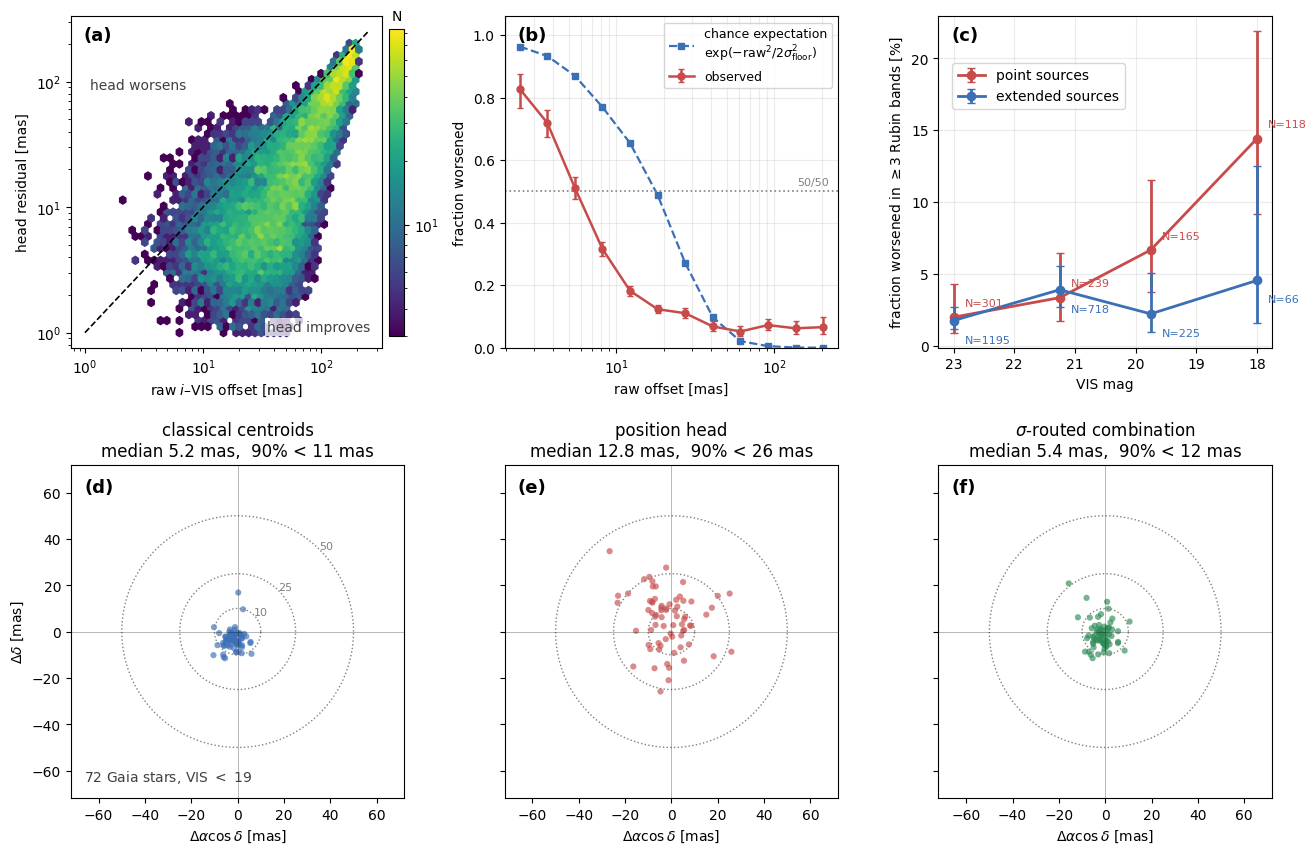

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import gridspec

C_CL='#3b6fb6'; C_HEAD='#c84b4b'; C_ROUT='#2e8b57'
fig=plt.figure(figsize=(15.5,10.4))
gs=gridspec.GridSpec(2,3,height_ratios=[1.0,1.12],hspace=0.28,wspace=0.30)
axA=fig.add_subplot(gs[0,0]); axB=fig.add_subplot(gs[0,1]); axR=fig.add_subplot(gs[0,2])
axC=fig.add_subplot(gs[1,0]); axD=fig.add_subplot(gs[1,1],sharex=axC,sharey=axC)
axE=fig.add_subplot(gs[1,2],sharex=axC,sharey=axC)

# (a) symptom: head residual vs raw offset, i band
ib=long[long.band=='i']
hb=axA.hexbin(ib.raw,ib.res,gridsize=45,xscale='log',yscale='log',norm=LogNorm(),
              cmap='viridis',mincnt=3,extent=(0,2.4,0,2.4))
axA.plot([1,250],[1,250],'k--',lw=1.2)
cb=fig.colorbar(hb,ax=axA,fraction=0.046,pad=0.02)
cb.ax.set_title('N',fontsize=10)
TBOX=dict(fc='white',alpha=0.75,ec='none',pad=1.5)
axA.text(0.06,0.78,'head worsens',transform=axA.transAxes,fontsize=10,color='0.25',bbox=TBOX)
axA.text(0.96,0.05,'head improves',transform=axA.transAxes,fontsize=10,color='0.25',ha='right',bbox=TBOX)
axA.set(xlabel='raw $i$–VIS offset [mas]',ylabel='head residual [mas]')
axA.text(0.04,0.97,'(a)',transform=axA.transAxes,fontsize=13,fontweight='bold',va='top')

# (b) chance test: observed fraction worsened vs the noise-floor expectation
axB.errorbar(RCEN,fw_obs,yerr=[fw_obs-fw_lo,fw_hi-fw_obs],fmt='o-',ms=5,lw=1.8,capsize=2.5,
             color=C_HEAD,label='observed',zorder=3)
axB.plot(RCEN,fw_pred,'s--',ms=5,lw=1.6,color=C_CL,
         label='chance expectation\n$\\exp(-\\mathrm{raw}^2/2\\sigma_{\\rm floor}^2)$')
axB.axhline(0.5,color='gray',ls=':',lw=1.2)
axB.text(140,0.52,'50/50',fontsize=8,color='gray')
axB.set(xscale='log',xlabel='raw offset [mas]',ylabel='fraction worsened',ylim=(0,1.06))
axB.grid(True,alpha=0.25,which='both'); axB.legend(fontsize=9,loc='upper right')
axB.text(0.04,0.97,'(b)',transform=axB.transAxes,fontsize=13,fontweight='bold',va='top')

# (c) identity: the star-brightness ramp of cannot-be-chance worseners
xc=[np.mean(b) for b in MB]
for cls,col,lab,dy in [('star',C_HEAD,'point sources',8),('extended',C_CL,'extended sources',-16)]:
    r,n=ramp[cls]
    lo_,hi_=zip(*[wilson(ri,ni) for ri,ni in zip(r,n)])
    axR.errorbar(xc,100*r,yerr=[100*(r-np.array(lo_)),100*(np.array(hi_)-r)],
                 fmt='o-',ms=6,lw=2,capsize=3,color=col,label=lab)
    for xi,ri,ni in zip(xc,r,n):
        axR.annotate(f'N={ni}',(xi,100*ri),textcoords='offset points',xytext=(8,dy),fontsize=8,color=col)
axR.invert_xaxis()
axR.set(xlabel='VIS mag',ylabel='fraction worsened in $\\geq$3 Rubin bands [%]')
axR.grid(True,alpha=0.25); axR.legend(fontsize=10,loc='upper left',bbox_to_anchor=(0.02,0.88))
axR.text(0.04,0.97,'(c)',transform=axR.transAxes,fontsize=13,fontweight='bold',va='top')

# (d-f) fix: bright Gaia stars vs PM-propagated Gaia DR3, held-out tiles
panels=[(axC,per.bx,per.by,'classical centroids',C_CL,'(d)'),
        (axD,per.hx,per.hy,'position head',C_HEAD,'(e)'),
        (axE,per.gx,per.gy,'$\\sigma$-routed combination',C_ROUT,'(f)')]
for ax,x,y,title,col,tag in panels:
    r=np.hypot(x,y)
    ax.scatter(x,y,s=20,alpha=0.65,color=col,edgecolors='none')
    for rad in [10,25,50]:
        th=np.linspace(0,2*np.pi,200)
        ax.plot(rad*np.cos(th),rad*np.sin(th),ls=':',color='gray',lw=1)
        if ax is axC: ax.annotate(f'{rad}',(rad/1.414,rad/1.414),fontsize=8,color='gray')
    ax.axhline(0,color='k',lw=0.5,alpha=0.4); ax.axvline(0,color='k',lw=0.5,alpha=0.4)
    ax.set(xlim=(-72,72),ylim=(-72,72),aspect='equal',xlabel=r'$\Delta\alpha\cos\delta$ [mas]',
           title=f'{title}\nmedian {np.median(r):.1f} mas,  90% < {np.percentile(r,90):.0f} mas')
    ax.text(0.04,0.96,tag,transform=ax.transAxes,fontsize=13,fontweight='bold',va='top')
axC.text(0.04,0.04,f'{len(per)} Gaia stars, VIS $<$ 19',transform=axC.transAxes,
         fontsize=10,color='0.25',va='bottom')
axC.set_ylabel(r'$\Delta\delta$ [mas]')
for ax in (axD,axE): plt.setp(ax.get_yticklabels(),visible=False)

OUT.parent.mkdir(parents=True,exist_ok=True)
fig.savefig(OUT,dpi=200,bbox_inches='tight'); print('saved',OUT.relative_to(REPO)); plt.show()

In [5]:
# numbers for the paper text (held-out half)
rows=['all sources','bright stars (VIS<19.5)','faint (S/N<10)']
sel=[test.index,test.index[test.bright_star],test.index[test.snr<10]]
summary=pd.DataFrame({c:[test.loc[s,c].median() for s in sel]
    for c in ['raw','res','comb','comb2']},index=rows).round(1)
summary.columns=['classical','head','naive IV','corr-aware router']
print('median radial offset [mas], held-out tiles:'); print(summary)
wf=lambda c:(test[test.bright_star][c]>test[test.bright_star]['raw']).mean()
print(f"\nbright stars worse than classical: head {wf('res'):.0%} -> naive IV {wf('comb'):.0%} -> corr-aware {wf('comb2'):.0%}")
rb=np.hypot(per.bx,per.by); rh=np.hypot(per.hx,per.hy); rr=np.hypot(per.gx,per.gy)
print(f'\nGaia truth (VIS<19 stars, N={len(per)}): classical {np.median(rb):.1f} | head {np.median(rh):.1f} | router {np.median(rr):.1f} mas')
ib_=long[long.band=='i']
print(f'\n(a) i band: {len(ib_):,} sources, fraction above 1:1 = {(ib_.res>ib_.raw).mean():.1%}'
      f' (bright S/N>30: {(ib_.res>ib_.raw)[ib_.snr>30].mean():.1%})')

median radial offset [mas], held-out tiles:
                         classical  head  naive IV  corr-aware router
all sources                   50.6  14.6      16.7               14.7
bright stars (VIS<19.5)       16.5  11.5      10.8               11.3
faint (S/N<10)                64.9  18.5      21.0               18.5

bright stars worse than classical: head 38% -> naive IV 25% -> corr-aware 16%

Gaia truth (VIS<19 stars, N=72): classical 5.2 | head 12.8 | router 5.4 mas

(a) i band: 18,178 sources, fraction above 1:1 = 10.6% (bright S/N>30: 22.7%)
